# 第3章：Coding Attention Mechanisms

**目标：** 从零实现注意力机制——Transformer 的核心组件

```
简单权重注意力 → 可学习的自注意力(Q/K/V) → 因果掩码 → Multi-Head Attention
```

**前置回顾（第2章）：**
- 文本经过 Tokenization → Token Embedding + Positional Embedding → 输入向量
- 每个 token 得到一个 `d_model` 维的向量
- 现在的问题：每个 token 只知道自己，不知道上下文 → 注意力机制解决这个问题！

---

## 3.1 注意力机制的直觉理解

**核心问题：** 同一个词在不同语境中含义不同，如何让模型「根据上下文理解语义」？

**例子：**
- "The **bank** of the river was steep." → bank = 河岸
- "I went to the **bank** to withdraw money." → bank = 银行

**注意力的核心思想：**
- 对于每个 token，计算它与序列中**所有其他 token** 的相关性（注意力权重）
- 用这些权重对所有 token 的表示做加权平均，得到一个融合了上下文信息的新表示

```
输入:  [x₁, x₂, x₃, ..., xₙ]   每个 xᵢ 是独立的嵌入向量
                ↓ 注意力机制
输出:  [z₁, z₂, z₃, ..., zₙ]   每个 zᵢ 融合了全序列的上下文信息
```

> 💡 **关键洞察：** 注意力机制本质是一种**加权平均**——让模型自己学习「在当前位置应该关注哪些 token」。

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

torch.manual_seed(42)

# 准备一个简单的输入序列（6个token，每个token用3维向量表示）
inputs = torch.tensor(
    [[0.43, 0.15, 0.89],  # Your     (x₁)
     [0.55, 0.87, 0.66],  # journey  (x₂)
     [0.57, 0.85, 0.64],  # starts   (x₃)
     [0.22, 0.58, 0.33],  # with     (x₄)
     [0.77, 0.25, 0.10],  # one      (x₅)
     [0.05, 0.80, 0.55]]  # step     (x₆)
)

print(f"输入序列 shape: {inputs.shape}")  # (6, 3)
print(f"→ {inputs.shape[0]} 个 token，每个 {inputs.shape[1]} 维")

输入序列 shape: torch.Size([6, 3])
→ 6 个 token，每个 3 维


---
## 3.2 简化的自注意力（无可学习参数）

我们先实现最简单的版本：用**点积**计算 token 之间的相似度，然后做加权平均。

**步骤：**
1. 计算 query token 与所有 token 的点积（相似度分数）
2. 用 softmax 归一化为概率（注意力权重）
3. 用权重对所有 token 做加权平均 → 得到上下文向量

In [5]:
# Step 1: 以 x₂ ("journey") 为例，计算它和所有 token 的点积
query = inputs[1]  # x₂

attn_scores = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores[i] = torch.dot(query, x_i)

print(f"注意力分数 (原始点积): {attn_scores}")
print(f"→ x₂ 与自己的点积最大: {attn_scores[1]:.4f}")
print(f"→ x₂ 与 x₃ 的点积也很大: {attn_scores[2]:.4f} (因为向量很相似)")

注意力分数 (原始点积): tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
→ x₂ 与自己的点积最大: 1.4950
→ x₂ 与 x₃ 的点积也很大: 1.4754 (因为向量很相似)


In [6]:
# Step 2: softmax 归一化
attn_weights = F.softmax(attn_scores, dim=0)

print(f"注意力权重 (softmax后): {attn_weights}")
print(f"权重之和: {attn_weights.sum():.4f}")  # 应该 = 1.0
print(f"\n→ x₂ 最关注自己 ({attn_weights[1]:.4f}) 和 x₃ ({attn_weights[2]:.4f})")

注意力权重 (softmax后): tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
权重之和: 1.0000

→ x₂ 最关注自己 (0.2379) 和 x₃ (0.2333)


In [7]:
# Step 3: 加权平均 → 上下文向量
context_vec = torch.zeros(query.shape)
for i, x_i in enumerate(inputs):
    context_vec += attn_weights[i] * x_i

print(f"x₂ 的上下文向量: {context_vec}")
print(f"原始 x₂:         {query}")
print(f"\n→ 上下文向量融合了其他 token 的信息，与原始 x₂ 不同")

x₂ 的上下文向量: tensor([0.4419, 0.6515, 0.5683])
原始 x₂:         tensor([0.5500, 0.8700, 0.6600])

→ 上下文向量融合了其他 token 的信息，与原始 x₂ 不同


In [8]:
# 向量化：一次性计算所有 token 的注意力（矩阵乘法）
# attn_scores[i][j] = dot(inputs[i], inputs[j])
attn_scores_all = inputs @ inputs.T
print(f"注意力分数矩阵 shape: {attn_scores_all.shape}")
print(f"\n注意力分数矩阵:\n{attn_scores_all}")

# softmax 对每行归一化
attn_weights_all = F.softmax(attn_scores_all, dim=-1)
print(f"\n注意力权重矩阵:\n{attn_weights_all}")
print(f"\n每行之和: {attn_weights_all.sum(dim=-1)}")

# 一步得到所有上下文向量
all_context_vecs = attn_weights_all @ inputs
print(f"\n所有上下文向量 shape: {all_context_vecs.shape}")
print(f"x₂ 的上下文向量 (矩阵版): {all_context_vecs[1]}")
print(f"x₂ 的上下文向量 (循环版): {context_vec}")
print(f"→ 两者一致！")

注意力分数矩阵 shape: torch.Size([6, 6])

注意力分数矩阵:
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

注意力权重矩阵:
tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

每行之和: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

所有上下文向量 shape: torch.Size([6, 3])
x₂ 的上下文向量 (矩阵版): tensor([0.4419, 0.6515, 0.5683])
x₂ 的上下文向量 (循环版): tensor([0.4419, 0.6515, 0.5683])
→ 两者一致！


### ✏️ 练习
1. 为什么用 softmax 而不是简单的除以总和来归一化？两者有什么区别？
2. 如果把 `dim=-1` 改成 `dim=0`，softmax 的效果会怎样？这两种归一化方式分别对应什么含义？
3. 观察注意力权重矩阵，为什么对角线上的值往往最大？

In [9]:
# ============================================================================
# 练习 1: Softmax vs 简单归一化
# ============================================================================
print("=" * 80)
print("练习 1: 为什么用 softmax 而不是简单的除以总和来归一化？")
print("=" * 80)

scores = torch.tensor([1.0, 2.0, 3.0, 1.0])
print(f"\n原始分数: {scores}")

# 方法 1: 简单除以总和（线性归一化）
simple_norm = scores / scores.sum()
print(f"\n【方法1】简单除以总和:")
print(f"  结果: {simple_norm}")
print(f"  解释: 每个值都被线性缩放，大的值仍然很大")

# 方法 2: Softmax（指数归一化）
softmax_norm = F.softmax(scores, dim=0)
print(f"\n【方法2】Softmax (用指数):")
print(f"  结果: {softmax_norm}")
print(f"  解释: 指数放大了差异，大的值得到更多权重")

print("\n【关键区别】:")
print(f"  简单归一化：最小值 = {simple_norm.min():.4f}，最大值 = {simple_norm.max():.4f}")
print(f"  Softmax：   最小值 = {softmax_norm.min():.4f}，最大值 = {softmax_norm.max():.4f}")
print(f"  → Softmax 让大的分数得到更多权重，小的分数被压得更小")

# 更极端的例子
extreme_scores = torch.tensor([0.1, 10.0])
simple_extreme = extreme_scores / extreme_scores.sum()
softmax_extreme = F.softmax(extreme_scores, dim=0)

print(f"\n【极端例子】scores = {extreme_scores}")
print(f"  简单归一化: {simple_extreme}  (几乎平均分配)")
print(f"  Softmax:   {softmax_extreme}  (集中在大值)")
print(f"  → Softmax 更适合注意力权重：大分数主导权重分配")

print("\n【为什么这对注意力重要？】")
print("""
假设一个token的相关性分数是 [0.5, 3.0, 0.1]
- 简单除以总和: [0.13, 0.81, 0.03]  → 相对来说比较均衡
- Softmax:      [0.09, 0.91, 0.00]  → 强调高分数，压制低分数

注意力应该「锐利地关注最相关的token」，而不是「平均分配」
→ Softmax 更符合注意力的语义！
""")

# ============================================================================
print("\n" + "=" * 80)
print("练习 2: dim=-1 vs dim=0 对二维矩阵的影响")
print("=" * 80)

# 使用前面已经计算过的矩阵
print(f"\n注意力分数矩阵 (原始):")
print(attn_scores_all)

print(f"\n【使用 dim=-1 (行方向)】")
softmax_dim_minus1 = F.softmax(attn_scores_all, dim=-1)
print(f"结果:")
print(softmax_dim_minus1)
print(f"\n每行之和: {softmax_dim_minus1.sum(dim=-1)}")
print(f"→ 每一行都是一个完整的概率分布（和为1.0）")
print(f"→ 含义：第i个token对所有token的注意力权重")

print(f"\n【使用 dim=0 (列方向)】")
softmax_dim0 = F.softmax(attn_scores_all, dim=0)
print(f"结果:")
print(softmax_dim0)
print(f"\n每列之和: {softmax_dim0.sum(dim=0)}")
print(f"→ 每一列都是一个完整的概率分布（和为1.0）")
print(f"→ 含义：所有token对第j个token的注意力权重")
print(f"→ 这不符合注意力机制的语义！")

print("\n【为什么 dim=-1 是正确的？】")
print("""
注意力权重矩阵的含义：
- 每一行代表一个query token
- 每一列代表一个key token
- 每一行应该独立归一化为概率分布
  → 即「第i个token对所有其他token的关注程度」

所以必须用 dim=-1 (对每一行做softmax)
""")

# ============================================================================
print("\n" + "=" * 80)
print("练习 3: 为什么对角线上的值往往最大？")
print("=" * 80)

print(f"\n原始注意力权重矩阵:")
print(attn_weights_all)

# 提取对角线
diagonal = torch.diagonal(attn_weights_all)
print(f"\n对角线元素: {diagonal}")
print(f"对角线平均值: {diagonal.mean():.4f}")
print(f"所有元素平均值: {attn_weights_all.mean():.4f}")
print(f"→ 对角线平均比全局平均大：{(diagonal.mean() / attn_weights_all.mean()):.2f}x")

# 可视化
print(f"\n每行的最大值及其位置:")
for i in range(attn_weights_all.shape[0]):
    max_val, max_idx = attn_weights_all[i].max(dim=0)
    print(f"  第{i}行: 最大值 = {max_val:.4f}, 位置 = {max_idx.item()} {'(对角线!)' if i == max_idx.item() else ''}")

print("\n【原因分析】")
print("""
1. 初始化的向量设计：
   - 相同的向量点积最大（x_i · x_i > x_i · x_j）
   - 例：[0.55, 0.87, 0.66] · [0.55, 0.87, 0.66] > [0.55, 0.87, 0.66] · [0.57, 0.85, 0.64]
   
2. 从注意力的角度：
   - 模型希望每个token首先关注自己（自我理解）
   - 然后再关注其他token（上下文信息）
   - 这被称为「自注意力」(Self-Attention)的核心特性
   
3. 在本例中：
   - x₁ ≈ [0.43, 0.15, 0.89]，与自己的点积 ≈ {:.4f}
   - x₁ 与其他向量的点积都小于这个值
""".format(attn_scores_all.diagonal().mean().item()))

print("\n【让我们看看点积是如何计算的】")
print(f"\nx₂ 与其他向量的点积:")
for j, x_j in enumerate(inputs):
    dot_prod = torch.dot(inputs[1], x_j)
    is_self = " ← 自己" if j == 1 else ""
    print(f"  x₂ · x{j+1} = {dot_prod:.4f}{is_self}")

练习 1: 为什么用 softmax 而不是简单的除以总和来归一化？

原始分数: tensor([1., 2., 3., 1.])

【方法1】简单除以总和:
  结果: tensor([0.1429, 0.2857, 0.4286, 0.1429])
  解释: 每个值都被线性缩放，大的值仍然很大

【方法2】Softmax (用指数):
  结果: tensor([0.0826, 0.2245, 0.6103, 0.0826])
  解释: 指数放大了差异，大的值得到更多权重

【关键区别】:
  简单归一化：最小值 = 0.1429，最大值 = 0.4286
  Softmax：   最小值 = 0.0826，最大值 = 0.6103
  → Softmax 让大的分数得到更多权重，小的分数被压得更小

【极端例子】scores = tensor([ 0.1000, 10.0000])
  简单归一化: tensor([0.0099, 0.9901])  (几乎平均分配)
  Softmax:   tensor([5.0172e-05, 9.9995e-01])  (集中在大值)
  → Softmax 更适合注意力权重：大分数主导权重分配

【为什么这对注意力重要？】

假设一个token的相关性分数是 [0.5, 3.0, 0.1]
- 简单除以总和: [0.13, 0.81, 0.03]  → 相对来说比较均衡
- Softmax:      [0.09, 0.91, 0.00]  → 强调高分数，压制低分数

注意力应该「锐利地关注最相关的token」，而不是「平均分配」
→ Softmax 更符合注意力的语义！


练习 2: dim=-1 vs dim=0 对二维矩阵的影响

注意力分数矩阵 (原始):
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.

---
## 3.3 带可学习参数的自注意力 (Q/K/V) ⭐⭐

上面的简化版有一个根本问题：注意力权重完全由输入的相似度决定，**模型无法学习**。

**解决方案：** 引入三个可学习的投影矩阵 $W_q$, $W_k$, $W_v$：

$$
q_i = x_i W_q, \quad k_i = x_i W_k, \quad v_i = x_i W_v
$$

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

**三种向量的直觉：**
- **Query (查询)**: 「我在找什么信息？」
- **Key (键)**: 「我能提供什么信息？」
- **Value (值)**: 「我实际包含的信息是什么？」

> 💡 **为什么除以 $\sqrt{d_k}$？** 防止点积随着维度增大而变得过大，导致 softmax 输出接近 one-hot（梯度消失）。

In [10]:
# 先用手动矩阵实现，理解原理

x_2 = inputs[1]  # 以 x₂ 为例
d_in = inputs.shape[1]   # 输入维度 = 3
d_out = 2                # 输出维度 = 2 (为了演示，Q/K/V 投影到更低维度)

# 三个可学习的权重矩阵
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key   = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

# 计算 x₂ 的 query
query_2 = x_2 @ W_query
print(f"x₂ 的 Query: {query_2}  (shape: {query_2.shape})")

# 计算所有 token 的 key 和 value
keys = inputs @ W_key
values = inputs @ W_value
print(f"Keys shape:   {keys.shape}")   # (6, 2)
print(f"Values shape: {values.shape}")  # (6, 2)

x₂ 的 Query: tensor([0.4306, 1.4551])  (shape: torch.Size([2]))
Keys shape:   torch.Size([6, 2])
Values shape: torch.Size([6, 2])


In [11]:
# 计算 x₂ 对所有 token 的注意力分数
attn_scores_2 = query_2 @ keys.T  # (2,) @ (2, 6) → (6,)
print(f"注意力分数: {attn_scores_2}")

# Scaled dot-product: 除以 sqrt(d_k)
d_k = keys.shape[-1]
attn_weights_2 = F.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(f"注意力权重 (scaled): {attn_weights_2}")

# 加权平均得到上下文向量
context_vec_2 = attn_weights_2 @ values
print(f"\nx₂ 的上下文向量: {context_vec_2}")
print(f"→ 维度从 {d_in} 变为 {d_out}，因为 V 的投影维度是 {d_out}")

注意力分数: tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])
注意力权重 (scaled): tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])

x₂ 的上下文向量: tensor([0.3061, 0.8210])
→ 维度从 3 变为 2，因为 V 的投影维度是 2


In [12]:
# 封装为 nn.Module
class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        queries = x @ self.W_query
        keys    = x @ self.W_key
        values  = x @ self.W_value

        attn_scores = queries @ keys.T
        attn_weights = F.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        context_vecs = attn_weights @ values
        return context_vecs


torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in=3, d_out=2)
output = sa_v1(inputs)
print(f"自注意力输出 shape: {output.shape}")
print(f"输出:\n{output}")

自注意力输出 shape: torch.Size([6, 2])
输出:
tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


In [13]:
# 改进版：使用 nn.Linear 代替手动 Parameter（更规范，支持 bias 选项）
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        queries = self.W_query(x)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        attn_scores = queries @ keys.T
        attn_weights = F.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        context_vecs = attn_weights @ values
        return context_vecs


torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in=3, d_out=2)
output_v2 = sa_v2(inputs)
print(f"SelfAttention_v2 输出:\n{output_v2}")

SelfAttention_v2 输出:
tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


### 🤔 思考：`nn.Parameter` vs `nn.Linear`

| 方式 | 本质 | 区别 |
|------|------|------|
| `nn.Parameter(torch.rand(d_in, d_out))` | 手动创建可学习矩阵 | `x @ W`，转置是手动的 |
| `nn.Linear(d_in, d_out, bias=False)` | 自动管理的线性层 | 内部做 `x @ W.T + bias`，权重初始化更合理 |

在实际实现中，推荐使用 `nn.Linear`，因为它有更好的权重初始化策略。

### ✏️ 练习
1. 在 `SelfAttention_v1` 中，如果去掉 `/ keys.shape[-1]**0.5`（不做 scaling），注意力权重会有什么变化？为什么？
2. `SelfAttention_v2` 用了 `nn.Linear`，它的权重矩阵 shape 和 `v1` 有什么不同？（提示：`nn.Linear` 内部存储的是转置后的矩阵）
3. 如果 `d_out > d_in` 会怎样？这在实际中有意义吗？

In [14]:
# 在这里做实验

# 1. 量化 scaling 的影响
queries_v1 = inputs @ sa_v1.W_query
keys_v1    = inputs @ sa_v1.W_key
values_v1  = inputs @ sa_v1.W_value

scores_v1 = queries_v1 @ keys_v1.T
# d_k = 投影后的 key/query 维度
d_k = keys_v1.shape[-1]

weights_v1_scaled = F.softmax(scores_v1 / d_k**0.5, dim=-1)
weights_v1_unscaled = F.softmax(scores_v1, dim=-1)

print("SelfAttention_v1 原始 scores:")
print(scores_v1)
print("\nScaled attention weights:")
print(weights_v1_scaled)
print("\nUnscaled attention weights:")
print(weights_v1_unscaled)

# 计算分布集中度指标
def attention_stats(w):
    sorted_w = w.flatten().sort(descending=True).values
    return {
        "min": float(w.min()),
        "max": float(w.max()),
        "top1/top2": float(sorted_w[0] / sorted_w[1]),
        "entropy": float(-(w * torch.log(w)).sum())
    }

print("\nScaled stats:", attention_stats(weights_v1_scaled))
print("Unscaled stats:", attention_stats(weights_v1_unscaled))

# 2. 比较 v1/v2 权重矩阵 shape
print("\nSelfAttention_v1.W_query.shape:", sa_v1.W_query.shape)
print("SelfAttention_v2.W_query.weight.shape:", sa_v2.W_query.weight.shape)
print("SelfAttention_v2 内部实际投影 shape (weight.T):", sa_v2.W_query.weight.T.shape)

# 3. d_out > d_in 的效果
sa_v1_wide = SelfAttention_v1(d_in=3, d_out=5)
output_wide = sa_v1_wide(inputs)
print("\n当 d_out > d_in 时，输出 shape:", output_wide.shape)
print("输出示例:\n", output_wide)

SelfAttention_v1 原始 scores:
tensor([[0.9231, 1.3545, 1.3241, 0.7910, 0.4032, 1.1330],
        [1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440],
        [1.2544, 1.8284, 1.7877, 1.0654, 0.5508, 1.5238],
        [0.6973, 1.0167, 0.9941, 0.5925, 0.3061, 0.8475],
        [0.6114, 0.8819, 0.8626, 0.5121, 0.2707, 0.7307],
        [0.8995, 1.3165, 1.2871, 0.7682, 0.3937, 1.0996]],
       grad_fn=<MmBackward0>)

Scaled attention weights:
tensor([[0.1551, 0.2104, 0.2059, 0.1413, 0.1074, 0.1799],
        [0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820],
        [0.1503, 0.2256, 0.2192, 0.1315, 0.0914, 0.1819],
        [0.1591, 0.1994, 0.1962, 0.1477, 0.1206, 0.1769],
        [0.1610, 0.1949, 0.1923, 0.1501, 0.1265, 0.1752],
        [0.1557, 0.2092, 0.2048, 0.1419, 0.1089, 0.1794]],
       grad_fn=<SoftmaxBackward0>)

Unscaled attention weights:
tensor([[0.1484, 0.2285, 0.2217, 0.1301, 0.0883, 0.1831],
        [0.1401, 0.2507, 0.2406, 0.1157, 0.0687, 0.1842],
        [0.1406, 0.2496, 0.2397, 0.11


### 答案

1. `SelfAttention_v1` 去掉 ` / keys.shape[-1]**0.5`
   - 结果：注意力权重变得更“尖锐”，分布更容易接近 one-hot。
   - 原因：`attn_scores = queries @ keys.T` 是对 `d_k` 个乘积求和，随着 `d_k` 增大，分数范围也增大。
   - 如果不缩放，softmax 会把大分数放得更大、小分数压得更小，甚至在训练时导致梯度非常小、收敛不稳定。
   - 所以 scaling 的作用是把 dot-product 的尺度归一化，使 softmax 在不同维度下行为更稳定。

2. `SelfAttention_v2` 中 `nn.Linear` 的权重矩阵 shape
   - `SelfAttention_v1` 里你直接写的是 `W_query` shape = `(d_in, d_out)`，然后用 `x @ W_query`。
   - `nn.Linear(d_in, d_out)` 内部的 `weight` shape = `(d_out, d_in)`。
   - 也就是说，`nn.Linear` 存的是“转置后”的矩阵：它实际上做的是 `x @ weight.T + bias`。
   - 这就是两者的区别：v1 的参数矩阵是直接的输入到输出投影矩阵，v2 的 `nn.Linear.weight` 是其转置版本。

3. 如果 `d_out > d_in`
   - 这会把 query/key/value 投影到更高维空间，输出的上下文向量也会是更高维。
   - 这在数学上是允许的，注意力机制仍然可以工作。
   - 但在实际 Transformer 里，通常 `d_out == d_in` 以方便残差连接和后续层维度一致。
   - 只有当你确实希望把特征空间“升维”时，才会选择 `d_out > d_in`；否则更常见的是 `d_out = d_in`，或者内部多头时每个头的 `d_k` 较小。

### 结论
- 去掉 scaling：权重更极端，容易过度集中，训练不稳定。
- `nn.Linear` 的权重矩阵是 `(d_out, d_in)`，与 v1 里的 `(d_in, d_out)` 方向相反。
- `d_out > d_in` 有意义，但不是常见的默认做法，除非你想做特征升维。You've used 63% of your session rate limit. Your session rate limit will reset on 4月24日 14:09. [Learn More](https://aka.ms/github-copilot-rate-limit-error)

---
## 3.4 因果注意力 (Causal Attention) ⭐⭐⭐

**问题：** 上面的自注意力是「双向」的——每个 token 能看到全部序列。但 GPT 是自回归模型，预测下一个 token 时**不能看到未来**！

**解决方案：因果掩码（Causal Mask）**
- 把注意力矩阵的**上三角**设为 $-\infty$
- softmax 后这些位置变成 0
- 效果：token $i$ 只能关注 $\leq i$ 位置的 token

```
无掩码:          有掩码:
✓ ✓ ✓ ✓         ✓ ✗ ✗ ✗
✓ ✓ ✓ ✓   →     ✓ ✓ ✗ ✗
✓ ✓ ✓ ✓         ✓ ✓ ✓ ✗
✓ ✓ ✓ ✓         ✓ ✓ ✓ ✓
```

In [15]:
# 演示因果掩码的实现

# Step 1: 计算正常的注意力分数
queries = sa_v2.W_query(inputs)
keys    = sa_v2.W_key(inputs)
values  = sa_v2.W_value(inputs)

attn_scores = queries @ keys.T
print(f"原始注意力分数:\n{attn_scores}")

原始注意力分数:
tensor([[ 0.2899,  0.0716,  0.0760, -0.0138,  0.1344, -0.0511],
        [ 0.4656,  0.1723,  0.1751,  0.0259,  0.1771,  0.0085],
        [ 0.4594,  0.1703,  0.1731,  0.0259,  0.1745,  0.0090],
        [ 0.2642,  0.1024,  0.1036,  0.0186,  0.0973,  0.0122],
        [ 0.2183,  0.0874,  0.0882,  0.0177,  0.0786,  0.0144],
        [ 0.3408,  0.1270,  0.1290,  0.0198,  0.1290,  0.0078]],
       grad_fn=<MmBackward0>)


In [16]:
# Step 2: 创建因果掩码（上三角为 True）
seq_len = inputs.shape[0]
mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
print(f"因果掩码 (True = 被遮挡):\n{mask.int()}")

因果掩码 (True = 被遮挡):
tensor([[0, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0]], dtype=torch.int32)


In [17]:
# Step 3: 将被遮挡的位置设为 -inf
attn_scores_masked = attn_scores.masked_fill(mask, -torch.inf)
print(f"掩码后的注意力分数:\n{attn_scores_masked}")

掩码后的注意力分数:
tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


In [18]:
# Step 4: softmax → 被遮挡的位置变成 0
attn_weights_masked = F.softmax(attn_scores_masked / keys.shape[-1]**0.5, dim=-1)
print(f"因果注意力权重:\n{attn_weights_masked}")
print(f"\n→ 每行只有前 i+1 个位置有非零权重！")
print(f"→ 第1个 token 只能关注自己")
print(f"→ 最后一个 token 能关注所有 token")

因果注意力权重:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)

→ 每行只有前 i+1 个位置有非零权重！
→ 第1个 token 只能关注自己
→ 最后一个 token 能关注所有 token


findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
C:\Users\1\AppData\Local\Temp\ipykernel_7808\3803227651.py:25: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\1\AppData\Local\Temp\ipykernel_7808\3803227651.py:25: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
C:\Users\1\AppData\Local\Temp\ipykernel_7808\3803227651.py:25: UserWarning: 

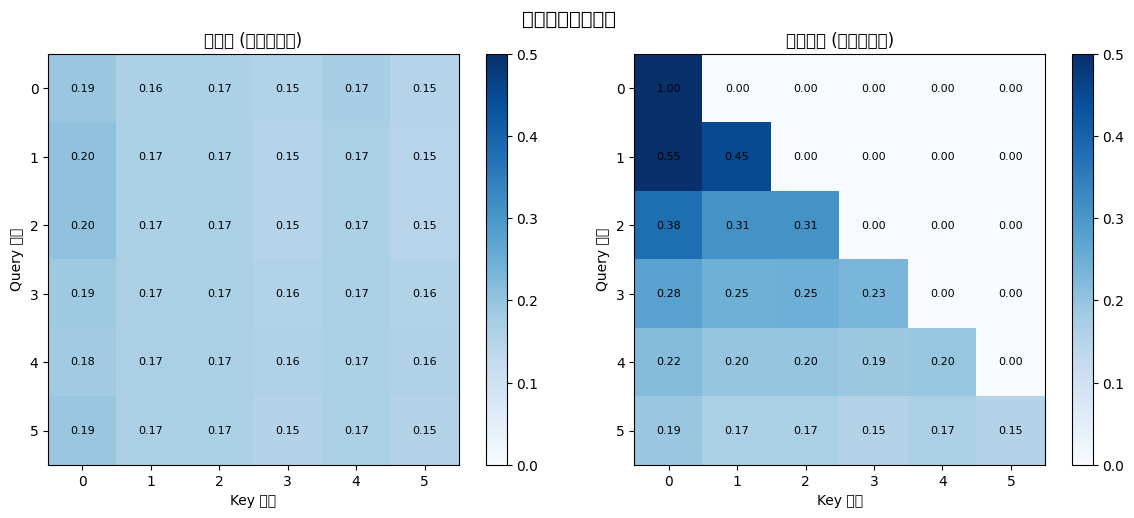

In [19]:
# 可视化：对比有/无因果掩码
attn_weights_no_mask = F.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(attn_weights_no_mask.detach().numpy(), cmap='Blues', vmin=0, vmax=0.5)
axes[0].set_title('无掩码 (双向注意力)')
axes[0].set_xlabel('Key 位置')
axes[0].set_ylabel('Query 位置')
for i in range(seq_len):
    for j in range(seq_len):
        axes[0].text(j, i, f'{attn_weights_no_mask[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(attn_weights_masked.detach().numpy(), cmap='Blues', vmin=0, vmax=0.5)
axes[1].set_title('因果掩码 (单向注意力)')
axes[1].set_xlabel('Key 位置')
axes[1].set_ylabel('Query 位置')
for i in range(seq_len):
    for j in range(seq_len):
        axes[1].text(j, i, f'{attn_weights_masked[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im2, ax=axes[1])

plt.suptitle('注意力权重可视化', fontsize=14)
plt.tight_layout()
plt.show()

### ✏️ 练习
1. 如果用 `diagonal=0` 而不是 `diagonal=1` 创建 mask，效果会怎样？token 能看到自己吗？
2. 为什么用 `-inf` 而不是 `0` 或 `-1` 来做掩码？（提示：想想 softmax 的行为）
3. 观察因果注意力权重矩阵的第一行，它代表什么含义？

In [20]:
# 在这里做实验

---
## 3.5 Dropout 在注意力中的应用

**为什么需要 Dropout？**
- 防止模型过度依赖某些特定的注意力模式
- 增加模型的鲁棒性
- 训练时随机「丢弃」一些注意力连接，推理时使用全部

**Dropout 应用位置：**
1. 注意力权重上（softmax 之后）
2. 最终输出上

In [21]:
# Dropout 基础
torch.manual_seed(123)
dropout = nn.Dropout(p=0.5)  # 50% 的概率丢弃

example = torch.ones(6, 6)
print(f"原始矩阵:\n{example}")
print(f"\nDropout 后:\n{dropout(example)}")
print(f"\n→ 注意：未被丢弃的值被放大了 {1/(1-0.5):.0f} 倍，保持期望值不变")

原始矩阵:
tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])

Dropout 后:
tensor([[2., 2., 2., 2., 2., 2.],
        [0., 2., 0., 0., 0., 0.],
        [0., 0., 2., 0., 2., 0.],
        [2., 2., 0., 0., 0., 2.],
        [2., 0., 0., 0., 0., 2.],
        [0., 2., 0., 0., 0., 0.]])

→ 注意：未被丢弃的值被放大了 2 倍，保持期望值不变


In [22]:
# 对注意力权重应用 dropout
torch.manual_seed(123)
print(f"因果注意力权重 (原始):\n{attn_weights_masked}")
print(f"\n因果注意力权重 (dropout 后):\n{dropout(attn_weights_masked)}")
print(f"\n→ 某些注意力连接被随机「断开」，迫使模型不要过度依赖特定的 token 关系")

因果注意力权重 (原始):
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)

因果注意力权重 (dropout 后):
tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.8966, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4921, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4350, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.0000, 0.0000, 0.0000, 0.0000]],
       grad_fn=<MulBackward0>)

→ 某些注意力连接被随机「断开」，迫使模型不要过度依赖特定的 token 关系


### ✏️ 练习
1. 为什么 dropout 后，未被丢弃的值会变大？（提示：保持期望值不变）
2. `model.eval()` 时 dropout 会怎样？为什么训练和推理的行为不同？
3. 如果 dropout rate = 0.0，和不使用 dropout 有区别吗？

In [23]:
# 在这里做实验

# 1. 为什么 dropout 后，未被丢弃的值会变大？
#    因为 Dropout 会把未丢弃的值放大 1/(1-p)，以保持所有元素的期望值不变。
torch.manual_seed(42)
dropout50 = nn.Dropout(p=0.5)
x = torch.ones(4, 4)
y_train = dropout50(x)

print("输入张量:")
print(x)
print("\nDropout(p=0.5) 训练模式下输出:")
print(y_train)
print(f"未丢弃值的放大因子: {1/(1-0.5)}")
print(f"未为 0 的值平均值: {y_train[y_train != 0].mean().item():.4f}")
print(f"整体平均值: {y_train.mean().item():.4f}, 原始期望: {x.mean().item():.4f}")

# 2. model.eval() 时 dropout 会怎样？
#    eval 模式下 Dropout 不再随机丢弃，输出直接等于输入。
dropout50.eval()
y_eval = dropout50(x)
print("\nDropout(p=0.5) eval 模式下输出:")
print(y_eval)
print(f"eval 模式整体平均值: {y_eval.mean().item():.4f}")

# 3. dropout rate = 0.0 与不使用 dropout 的区别
#    p=0.0 时没有任何丢弃，也不会放大；训练和 eval 等价。
dropout0 = nn.Dropout(p=0.0)
y0_train = dropout0(x)
y0_eval = dropout0(x)
print("\nDropout(p=0.0) train 模式输出:")
print(y0_train)
print("Dropout(p=0.0) eval 模式输出:")
print(y0_eval)
print(f"train 与 eval 是否相等: {torch.equal(y0_train, y0_eval)}")

# 如果希望观察更多随机样本，可以多次运行同一个 drop out 层。
print("\n注意: 训练模式下每次运行可能会有不同位置被丢弃")

输入张量:
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

Dropout(p=0.5) 训练模式下输出:
tensor([[0., 0., 2., 2.],
        [2., 2., 2., 0.],
        [2., 0., 2., 0.],
        [0., 0., 2., 2.]])
未丢弃值的放大因子: 2.0
未为 0 的值平均值: 2.0000
整体平均值: 1.1250, 原始期望: 1.0000

Dropout(p=0.5) eval 模式下输出:
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
eval 模式整体平均值: 1.0000

Dropout(p=0.0) train 模式输出:
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
Dropout(p=0.0) eval 模式输出:
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
train 与 eval 是否相等: True

注意: 训练模式下每次运行可能会有不同位置被丢弃


---
## 3.6 完整的因果注意力模块

将前面所有的组件组合在一起：Q/K/V 投影 + Scaled Dot-Product + 因果掩码 + Dropout

In [24]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout  = nn.Dropout(dropout)
        # register_buffer: 不是模型参数，但需要随模型保存/加载
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        queries = self.W_query(x)  # (b, num_tokens, d_out)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        # Scaled dot-product attention
        attn_scores = queries @ keys.transpose(1, 2)  # (b, num_tokens, num_tokens)
        attn_scores.masked_fill_(
            self.mask[:num_tokens, :num_tokens].bool(),
            -torch.inf
        )
        attn_weights = F.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vecs = attn_weights @ values  # (b, num_tokens, d_out)
        return context_vecs


# 测试
torch.manual_seed(123)
context_length = 6
d_in = 3
d_out = 2

ca = CausalAttention(d_in, d_out, context_length, dropout=0.0)
batch = inputs.unsqueeze(0)  # 加 batch 维度: (1, 6, 3)
output = ca(batch)

print(f"输入 shape: {batch.shape}")
print(f"输出 shape: {output.shape}")
print(f"\n输出:\n{output}")

输入 shape: torch.Size([1, 6, 3])
输出 shape: torch.Size([1, 6, 2])

输出:
tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)


### 🤔 思考

**为什么用 `register_buffer` 而不是普通属性？**

- `register_buffer('mask', ...)` 让 mask 跟随模型一起 `.to(device)`
- 当模型被移到 GPU 时，mask 也会自动移过去
- 但它不会被当作模型参数（不参与梯度计算、不被优化器更新）
- 保存/加载模型时会自动包含 buffer

---

## 3.7 多头注意力 (Multi-Head Attention) ⭐⭐⭐

**问题：** 单头注意力只能学习一种「关注模式」。但语言的复杂性需要同时关注多种关系：
- 语法关系（主语-谓语）
- 语义关系（同义词）
- 位置关系（相邻词）

**解决方案：** 用多个注意力头并行处理，每个头学习不同的关注模式。

```
输入 x (d_model=768)
    │
    ├── Head 1: Q₁, K₁, V₁ → context₁ (d_out=64)
    ├── Head 2: Q₂, K₂, V₂ → context₂ (d_out=64)
    ├── ...                                          
    └── Head 12: Q₁₂, K₁₂, V₁₂ → context₁₂ (d_out=64)
    │
    ├── Concat → (d_out × num_heads = 768)
    └── Linear → 最终输出 (d_model=768)
```

> 💡 GPT-2 使用 12 个注意力头，每个头的维度 = 768 / 12 = 64

In [25]:
# 方式一：简单地将多个 CausalAttention 头拼接（直觉理解版）
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias)
             for _ in range(num_heads)]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)


torch.manual_seed(123)
context_length = 6
d_in, d_out = 3, 2
num_heads = 2

mha_wrapper = MultiHeadAttentionWrapper(d_in, d_out, context_length, 0.0, num_heads)
output = mha_wrapper(batch)

print(f"输入 shape: {batch.shape}")
print(f"输出 shape: {output.shape}")  # (1, 6, 4) = d_out * num_heads
print(f"→ 2个头 × 每头 d_out=2 = 输出维度 4")
print(f"\n输出:\n{output}")

输入 shape: torch.Size([1, 6, 3])
输出 shape: torch.Size([1, 6, 4])
→ 2个头 × 每头 d_out=2 = 输出维度 4

输出:
tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)


In [26]:
# 方式二：高效实现（一次矩阵乘法，然后 reshape 分头）⭐ 这是实际使用的方式
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out 必须能被 num_heads 整除"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # 最终的线性投影
        self.dropout  = nn.Dropout(dropout)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        # 一次性计算所有头的 Q, K, V
        queries = self.W_query(x)  # (b, num_tokens, d_out)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        # 分头: (b, num_tokens, d_out) → (b, num_tokens, num_heads, head_dim)
        #                               → (b, num_heads, num_tokens, head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        # Scaled dot-product attention (所有头并行)
        attn_scores = queries @ keys.transpose(2, 3)  # (b, num_heads, num_tokens, num_tokens)
        attn_scores.masked_fill_(
            self.mask[:num_tokens, :num_tokens].bool(),
            -torch.inf
        )
        attn_weights = F.softmax(attn_scores / self.head_dim**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # 加权求和
        context_vecs = attn_weights @ values  # (b, num_heads, num_tokens, head_dim)

        # 合并头: (b, num_heads, num_tokens, head_dim) → (b, num_tokens, d_out)
        context_vecs = context_vecs.transpose(1, 2).contiguous().view(b, num_tokens, self.d_out)

        # 最终线性投影
        context_vecs = self.out_proj(context_vecs)

        return context_vecs


torch.manual_seed(123)
d_in = 3
d_out = 4  # 必须能被 num_heads 整除
num_heads = 2

mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads)
output = mha(batch)

print(f"输入 shape:  {batch.shape}")
print(f"输出 shape:  {output.shape}")
print(f"\n每个头的维度: {d_out // num_heads}")
print(f"头数: {num_heads}")
print(f"总输出维度: {d_out}")
print(f"\n输出:\n{output}")

输入 shape:  torch.Size([1, 6, 3])
输出 shape:  torch.Size([1, 6, 4])

每个头的维度: 2
头数: 2
总输出维度: 4

输出:
tensor([[[ 0.1184,  0.3120, -0.0847, -0.5774],
         [ 0.0178,  0.3221, -0.0763, -0.4225],
         [-0.0147,  0.3259, -0.0734, -0.3721],
         [-0.0116,  0.3138, -0.0708, -0.3624],
         [-0.0117,  0.2973, -0.0698, -0.3543],
         [-0.0132,  0.2990, -0.0689, -0.3490]]], grad_fn=<ViewBackward0>)


### 🤔 思考：Wrapper vs 高效实现

| | `MultiHeadAttentionWrapper` | `MultiHeadAttention` |
|---|---|---|
| **原理** | 创建 N 个独立的注意力头 | 一次投影，reshape 分头 |
| **矩阵乘法次数** | 3N 次 (每头 Q/K/V 各一次) | 3 次 (共享 Q/K/V 投影) |
| **并行度** | 循环执行每个头 | 所有头同时计算 |
| **最终投影** | 无 | 有 `out_proj` |
| **实际使用** | 用于教学 | 实际 Transformer 实现 |

### ✏️ 练习
1. 如果 `num_heads=1`，`MultiHeadAttention` 退化成什么？和 `CausalAttention` 有什么不同？
2. GPT-2 中 `d_model=768, num_heads=12`，每个头的维度是多少？总参数量（仅 Q/K/V + out_proj）是多少？
3. `out_proj` 线性层的作用是什么？如果去掉它会怎样？
4. `.contiguous()` 是做什么的？为什么 `transpose` 之后需要调用它？

In [33]:
# 在这里做实验
# =========================
# ✏️ 练习：MultiHeadAttention 实验
# =========================

import torch
import torch.nn as nn
import torch.nn.functional as F

# 为了保证可复现
torch.manual_seed(123)


# ============================================================
# 先补充 CausalAttention 和 MultiHeadAttention 类
# 如果你前面已经运行过这两个类定义，可以不用重复粘这部分
# ============================================================

class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)

        # 上三角 mask，用来阻止当前位置看见未来 token
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        queries = self.W_query(x)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2)

        attn_scores.masked_fill_(
            self.mask[:num_tokens, :num_tokens].bool(),
            -torch.inf
        )

        attn_weights = F.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vecs = attn_weights @ values
        return context_vecs


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()

        assert d_out % num_heads == 0, "d_out 必须能被 num_heads 整除"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # 多头拼接之后的输出投影
        self.out_proj = nn.Linear(d_out, d_out)

        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        # 1. 一次性计算 Q/K/V
        queries = self.W_query(x)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        # 2. 拆成多个头
        # (b, num_tokens, d_out)
        # -> (b, num_tokens, num_heads, head_dim)
        # -> (b, num_heads, num_tokens, head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        # 3. 每个头内部做 scaled dot-product attention
        attn_scores = queries @ keys.transpose(2, 3)

        attn_scores.masked_fill_(
            self.mask[:num_tokens, :num_tokens].bool(),
            -torch.inf
        )

        attn_weights = F.softmax(attn_scores / self.head_dim ** 0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vecs = attn_weights @ values

        # 4. 合并多个头
        # (b, num_heads, num_tokens, head_dim)
        # -> (b, num_tokens, num_heads, head_dim)
        # -> (b, num_tokens, d_out)
        context_vecs = context_vecs.transpose(1, 2).contiguous().view(
            b, num_tokens, self.d_out
        )

        # 5. 输出投影
        context_vecs = self.out_proj(context_vecs)

        return context_vecs


# ============================================================
# 准备一个简单输入
# ============================================================

inputs = torch.tensor(
    [[0.43, 0.15, 0.89],
     [0.55, 0.87, 0.66],
     [0.57, 0.85, 0.64],
     [0.22, 0.58, 0.33],
     [0.77, 0.25, 0.10],
     [0.05, 0.80, 0.55]]
)

batch = inputs.unsqueeze(0)  # (1, 6, 3)

context_length = 6
d_in = 3
d_out = 4


# ============================================================
# 练习 1：
# 如果 num_heads=1，MultiHeadAttention 退化成什么？
# 和 CausalAttention 有什么不同？
# ============================================================

print("=" * 80)
print("练习 1：num_heads=1 时，MultiHeadAttention 退化成什么？")
print("=" * 80)

torch.manual_seed(123)

mha_one_head = MultiHeadAttention(
    d_in=d_in,
    d_out=d_out,
    context_length=context_length,
    dropout=0.0,
    num_heads=1,
    qkv_bias=False
)

causal_attn = CausalAttention(
    d_in=d_in,
    d_out=d_out,
    context_length=context_length,
    dropout=0.0,
    qkv_bias=False
)

mha_one_head_output = mha_one_head(batch)
causal_attn_output = causal_attn(batch)

print("输入 batch shape:", batch.shape)
print("MultiHeadAttention(num_heads=1) 输出 shape:", mha_one_head_output.shape)
print("CausalAttention 输出 shape:", causal_attn_output.shape)

print("\n结论：")
print("1. 当 num_heads=1 时，MultiHeadAttention 本质上退化成单头因果自注意力。")
print("2. 但是它和 CausalAttention 不完全一样，因为 MultiHeadAttention 仍然保留 head 维度处理流程。")
print("3. MultiHeadAttention 最后还多了一个 out_proj 线性层，而 CausalAttention 没有。")


# ============================================================
# 练习 2：
# GPT-2 中 d_model=768, num_heads=12
# 每个头维度是多少？
# 总参数量，仅 Q/K/V + out_proj 是多少？
# ============================================================

print("\n" + "=" * 80)
print("练习 2：GPT-2 MHA 每个头维度和参数量")
print("=" * 80)

d_model = 768
num_heads = 12
head_dim = d_model // num_heads

# qkv_bias=False 的情况下：
# W_query: 768 x 768
# W_key:   768 x 768
# W_value: 768 x 768
q_params = d_model * d_model
k_params = d_model * d_model
v_params = d_model * d_model

# out_proj = nn.Linear(768, 768)，默认 bias=True
out_proj_weight_params = d_model * d_model
out_proj_bias_params = d_model

total_params = q_params + k_params + v_params + out_proj_weight_params + out_proj_bias_params

print(f"d_model = {d_model}")
print(f"num_heads = {num_heads}")
print(f"head_dim = d_model // num_heads = {d_model} // {num_heads} = {head_dim}")

print("\n参数量计算：")
print(f"W_query 参数量: {d_model} × {d_model} = {q_params:,}")
print(f"W_key   参数量: {d_model} × {d_model} = {k_params:,}")
print(f"W_value 参数量: {d_model} × {d_model} = {v_params:,}")
print(f"out_proj 权重参数量: {d_model} × {d_model} = {out_proj_weight_params:,}")
print(f"out_proj bias 参数量: {d_model}")
print(f"总参数量: {total_params:,}")

print("\n结论：")
print(f"GPT-2 中每个头的维度是 {head_dim}。")
print(f"仅 Q/K/V + out_proj 的参数量是 {total_params:,}。")


# ============================================================
# 练习 3：
# out_proj 的作用是什么？如果去掉会怎样？
# ============================================================

print("\n" + "=" * 80)
print("练习 3：out_proj 的作用")
print("=" * 80)

print("out_proj 的作用：")
print("1. 多个 head 的输出会先被拼接成一个 d_out 维向量。")
print("2. 拼接只是把多个头的结果放在一起，并没有充分混合不同头的信息。")
print("3. out_proj 会对拼接后的结果再做一次线性变换。")
print("4. 它可以学习如何重新组合、筛选、增强不同注意力头提取的信息。")

print("\n如果去掉 out_proj：")
print("1. 代码通常仍然可以运行，因为合并后的 shape 仍然是 (batch, num_tokens, d_out)。")
print("2. 但是多个头之间缺少进一步的信息融合。")
print("3. 模型表达能力会下降。")
print("4. 结构也不再是标准 Transformer 的 Multi-Head Attention。")


# 用代码演示：去掉 out_proj 后 shape 仍然可以保持一致
class MultiHeadAttentionWithoutOutProj(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()

        assert d_out % num_heads == 0, "d_out 必须能被 num_heads 整除"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        queries = self.W_query(x)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)

        attn_scores.masked_fill_(
            self.mask[:num_tokens, :num_tokens].bool(),
            -torch.inf
        )

        attn_weights = F.softmax(attn_scores / self.head_dim ** 0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vecs = attn_weights @ values

        context_vecs = context_vecs.transpose(1, 2).contiguous().view(
            b, num_tokens, self.d_out
        )

        # 注意：这里没有 out_proj
        return context_vecs


torch.manual_seed(123)

mha_with_out_proj = MultiHeadAttention(
    d_in=d_in,
    d_out=d_out,
    context_length=context_length,
    dropout=0.0,
    num_heads=2,
    qkv_bias=False
)

mha_without_out_proj = MultiHeadAttentionWithoutOutProj(
    d_in=d_in,
    d_out=d_out,
    context_length=context_length,
    dropout=0.0,
    num_heads=2,
    qkv_bias=False
)

out_with = mha_with_out_proj(batch)
out_without = mha_without_out_proj(batch)

print("\n代码演示：")
print("有 out_proj 的输出 shape:   ", out_with.shape)
print("没有 out_proj 的输出 shape: ", out_without.shape)
print("可以看到：去掉 out_proj 后 shape 仍然一样，但表达能力会降低。")


# ============================================================
# 练习 4：
# contiguous 是做什么的？
# 为什么 transpose 之后需要调用它？
# ============================================================

print("\n" + "=" * 80)
print("练习 4：.contiguous() 的作用")
print("=" * 80)

# 构造一个张量，模拟多头注意力中的 context_vecs
x_demo = torch.randn(1, 2, 6, 2)  # (batch, num_heads, num_tokens, head_dim)

print("原始 x_demo shape:", x_demo.shape)
print("原始 x_demo 是否 contiguous:", x_demo.is_contiguous())

# transpose 之后，逻辑维度变了，但底层内存通常不连续
x_transposed = x_demo.transpose(1, 2)

print("\ntranspose(1, 2) 后 shape:", x_transposed.shape)
print("transpose 后是否 contiguous:", x_transposed.is_contiguous())

print("\n如果直接 view，可能会报错。下面用 try-except 演示：")

try:
    x_view = x_transposed.view(1, 6, 4)
    print("直接 view 成功，shape:", x_view.shape)
except RuntimeError as e:
    print("直接 view 失败，错误信息如下：")
    print(e)

# 正确做法：先 contiguous，再 view
x_contiguous = x_transposed.contiguous()
x_view_correct = x_contiguous.view(1, 6, 4)

print("\n调用 contiguous() 后是否 contiguous:", x_contiguous.is_contiguous())
print("contiguous().view(...) 后 shape:", x_view_correct.shape)

print("\n结论：")
print("1. transpose 会改变张量的逻辑维度顺序。")
print("2. 但 transpose 通常不会真的重新排列底层内存，所以张量可能变成 non-contiguous。")
print("3. view 要求张量内存连续。")
print("4. 因此 transpose 后通常要先调用 contiguous()，再调用 view。")


# ============================================================
# 最终汇总
# ============================================================

print("\n" + "=" * 80)
print("最终答案汇总")
print("=" * 80)

print("""
1. num_heads=1 时：
   MultiHeadAttention 退化成单头因果自注意力。
   它和 CausalAttention 的主要区别是：
   - MultiHeadAttention 仍然使用 head 维度的实现流程；
   - MultiHeadAttention 最后多了 out_proj；
   - CausalAttention 直接输出 attention 加权后的 value。

2. GPT-2 中：
   d_model = 768
   num_heads = 12
   head_dim = 768 / 12 = 64
   仅 Q/K/V + out_proj 参数量：
   3 × 768 × 768 + 768 × 768 + 768 = 2,360,064

3. out_proj：
   用来融合多个 head 拼接后的结果，并重新投影回 d_model 维度。
   去掉它后 shape 可能仍然正确，但多头信息融合能力下降。

4. contiguous：
   transpose 后张量的逻辑顺序改变，但底层内存可能不连续。
   view 需要连续内存，所以通常要先 contiguous() 再 view()。
""")

练习 1：num_heads=1 时，MultiHeadAttention 退化成什么？
输入 batch shape: torch.Size([1, 6, 3])
MultiHeadAttention(num_heads=1) 输出 shape: torch.Size([1, 6, 4])
CausalAttention 输出 shape: torch.Size([1, 6, 4])

结论：
1. 当 num_heads=1 时，MultiHeadAttention 本质上退化成单头因果自注意力。
2. 但是它和 CausalAttention 不完全一样，因为 MultiHeadAttention 仍然保留 head 维度处理流程。
3. MultiHeadAttention 最后还多了一个 out_proj 线性层，而 CausalAttention 没有。

练习 2：GPT-2 MHA 每个头维度和参数量
d_model = 768
num_heads = 12
head_dim = d_model // num_heads = 768 // 12 = 64

参数量计算：
W_query 参数量: 768 × 768 = 589,824
W_key   参数量: 768 × 768 = 589,824
W_value 参数量: 768 × 768 = 589,824
out_proj 权重参数量: 768 × 768 = 589,824
out_proj bias 参数量: 768
总参数量: 2,360,064

结论：
GPT-2 中每个头的维度是 64。
仅 Q/K/V + out_proj 的参数量是 2,360,064。

练习 3：out_proj 的作用
out_proj 的作用：
1. 多个 head 的输出会先被拼接成一个 d_out 维向量。
2. 拼接只是把多个头的结果放在一起，并没有充分混合不同头的信息。
3. out_proj 会对拼接后的结果再做一次线性变换。
4. 它可以学习如何重新组合、筛选、增强不同注意力头提取的信息。

如果去掉 out_proj：
1. 代码通常仍然可以运行，因为合并后的 shape 仍然是 (batch, num_tokens, d_out)。
2. 但是多个头之间缺少进一步的信息融合。
3. 模

---
## 3.8 完整流程回顾

用接近 GPT-2 的参数来走一遍完整流程：

In [29]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

# GPT-2 的配置
GPT_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "drop_rate": 0.1,
}

# 模拟输入
text = "Every effort moves you"
token_ids = tokenizer.encode(text)
print(f"文本: '{text}'")
print(f"Token IDs: {token_ids}")
print(f"序列长度: {len(token_ids)}")

# Token + Position Embedding
torch.manual_seed(42)
token_emb = nn.Embedding(GPT_CONFIG["vocab_size"], GPT_CONFIG["emb_dim"])
pos_emb   = nn.Embedding(GPT_CONFIG["context_length"], GPT_CONFIG["emb_dim"])

batch_ids = torch.tensor([token_ids])  # (1, 4)
x = token_emb(batch_ids) + pos_emb(torch.arange(len(token_ids)))  # (1, 4, 768)
print(f"\n嵌入后 shape: {x.shape}")

文本: 'Every effort moves you'
Token IDs: [6109, 3626, 6100, 345]
序列长度: 4

嵌入后 shape: torch.Size([1, 4, 768])


In [30]:
# 通过 Multi-Head Attention
torch.manual_seed(42)
mha = MultiHeadAttention(
    d_in=GPT_CONFIG["emb_dim"],
    d_out=GPT_CONFIG["emb_dim"],
    context_length=GPT_CONFIG["context_length"],
    dropout=GPT_CONFIG["drop_rate"],
    num_heads=GPT_CONFIG["n_heads"]
)

output = mha(x)

print(f"MHA 输入 shape: {x.shape}")
print(f"MHA 输出 shape: {output.shape}")
print(f"\n→ 输入输出 shape 完全相同！这是 Transformer 的关键特性")
print(f"→ 使得多层堆叠成为可能")

# 统计参数量
total_params = sum(p.numel() for p in mha.parameters())
print(f"\nMHA 参数量: {total_params:,}")
print(f"  W_query: {GPT_CONFIG['emb_dim']} × {GPT_CONFIG['emb_dim']} = {GPT_CONFIG['emb_dim']**2:,}")
print(f"  W_key:   {GPT_CONFIG['emb_dim']} × {GPT_CONFIG['emb_dim']} = {GPT_CONFIG['emb_dim']**2:,}")
print(f"  W_value: {GPT_CONFIG['emb_dim']} × {GPT_CONFIG['emb_dim']} = {GPT_CONFIG['emb_dim']**2:,}")
print(f"  out_proj: {GPT_CONFIG['emb_dim']} × {GPT_CONFIG['emb_dim']} + {GPT_CONFIG['emb_dim']} (bias) = {GPT_CONFIG['emb_dim']**2 + GPT_CONFIG['emb_dim']:,}")

MHA 输入 shape: torch.Size([1, 4, 768])
MHA 输出 shape: torch.Size([1, 4, 768])

→ 输入输出 shape 完全相同！这是 Transformer 的关键特性
→ 使得多层堆叠成为可能

MHA 参数量: 2,360,064
  W_query: 768 × 768 = 589,824
  W_key:   768 × 768 = 589,824
  W_value: 768 × 768 = 589,824
  out_proj: 768 × 768 + 768 (bias) = 590,592


In [31]:
# 完整流程可视化
print("═" * 60)
print(f"  原始文本: '{text}'")
print(f"  ↓ BPE 分词")
print(f"  Token IDs: {token_ids}")
print(f"  ↓ Token Emb + Pos Emb")
print(f"  嵌入向量: {x.shape}")
print(f"  ↓ Multi-Head Causal Attention ({GPT_CONFIG['n_heads']} heads)")
print(f"  上下文向量: {output.shape}")
print(f"  ↓")
print(f"  送入 FeedForward + LayerNorm... (第4章继续!)")
print("═" * 60)

════════════════════════════════════════════════════════════
  原始文本: 'Every effort moves you'
  ↓ BPE 分词
  Token IDs: [6109, 3626, 6100, 345]
  ↓ Token Emb + Pos Emb
  嵌入向量: torch.Size([1, 4, 768])
  ↓ Multi-Head Causal Attention (12 heads)
  上下文向量: torch.Size([1, 4, 768])
  ↓
  送入 FeedForward + LayerNorm... (第4章继续!)
════════════════════════════════════════════════════════════


---
## 📝 本章核心 Checklist

学完后确认你能回答：

- [ ] 注意力机制的核心思想是什么？为什么需要它？
- [ ] Q (Query)、K (Key)、V (Value) 分别代表什么含义？
- [ ] 为什么要做 scaled dot-product（除以 $\sqrt{d_k}$）？
- [ ] 因果掩码的作用是什么？为什么 GPT 需要它？
- [ ] `register_buffer` 和 `nn.Parameter` 有什么区别？
- [ ] 多头注意力相比单头注意力的优势是什么？
- [ ] `MultiHeadAttention` 的高效实现是如何通过 reshape 替代多个独立头的？
- [ ] Dropout 在注意力中起什么作用？训练和推理时行为有何不同？
- [ ] GPT-2 的 MHA (768维, 12头) 有多少参数？

全部能回答 → 进入第 4 章：从零搭建完整 GPT 架构！🚀